# Feature Engineering — CMAPSS Turbofan Degradation

**Prerequisites** — before opening this notebook run:
```bash
python src/data/preprocessing.py --dataset all
```
That writes `data/processed/{DATASET}/train_preprocessed.csv` and
`test_preprocessed.csv` for all four datasets, plus the `models/{DATASET}/`
artifacts (kmeans, scalers).

**This notebook** runs `feature_engineering()` on top of those preprocessed
files, validates the outputs visually, and saves the final feature CSVs.
Change `DATASET` in cell 3 to switch between FD001–FD004.

## 0. Imports & Project Root

The root is located by walking up from the current working directory until a
`config/` folder is found — so the notebook runs correctly regardless of
whether Jupyter was launched from the project root, the `notebooks/` folder,
or anywhere else inside the project.

In [42]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root(marker: str = "config") -> Path:
    """Walk up from cwd until a directory containing 'marker' is found."""
    path = Path.cwd()
    for _ in range(6):
        if (path / marker).exists():
            return path
        path = path.parent
    raise RuntimeError(
        f"Could not find project root (looked for a '{marker}/' directory). "
        "Make sure you're running this notebook from inside the project."
    )


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src" / "data"))

from preprocessing import load_config
from feature_engineering import feature_engineering

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = ["#2563EB", "#16A34A", "#DC2626", "#D97706", "#7C3AED"]

print(f"Project root : {PROJECT_ROOT}")

Project root : c:\Users\sirde\Projects\Predictive Maintenance


## 1. Load Config & Preprocessed Data

Change `DATASET` to `FD002`, `FD003`, or `FD004` to run on any dataset.

In [ ]:
DATASET = "FD004"

CONFIG_PATH = PROJECT_ROOT / "config" / "datasets.yaml"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

cfg = load_config(str(CONFIG_PATH), DATASET)

display_cfg = {k: v for k, v in cfg.items()
               if k not in ("columns", "sensor_cols", "feature_cols")}
print("Active config:")
for k, v in display_cfg.items():
    print(f"  {k}: {v}")

Active config:
  n_clusters: 6
  max_rul: 125
  window_size: 50
  n_train_engines: 248
  n_test_engines: 249
  fault_modes: ['HPC', 'fan']
  single_condition: False
  dataset_name: FD004
  artifact_dir: models\FD004


In [ ]:
train_raw = pd.read_csv(PROCESSED_DIR / DATASET / "train_preprocessed.csv")
test_raw = pd.read_csv(PROCESSED_DIR / DATASET / "test_preprocessed.csv")

print(f"Train : {train_raw.shape[0]:>6,} rows  {train_raw.shape[1]:>3} cols  "
      f"{train_raw['unit_number'].nunique()} engines")
print(f"Test  : {test_raw.shape[0]:>6,} rows  {test_raw.shape[1]:>3} cols  "
      f"{test_raw['unit_number'].nunique()} engines")
print(f"\nRUL range (train): [{train_raw['RUL'].min():.0f}, {train_raw['RUL'].max():.0f}]")
print(f"Columns: {list(train_raw.columns)}")

Train : 61,249 rows   27 cols  249 engines
Test  : 41,214 rows   27 cols  248 engines

RUL range (train): [0, 542]
Columns: ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL', 'op_cluster']


## 2. RUL Distribution Before Clipping

The sharp peak at `max_rul` after clipping is intentional — early-life cycles all
receive the same label, removing the misleading gradient at the top of the range
and preventing the model from wasting capacity learning to distinguish RUL 200 from 250.

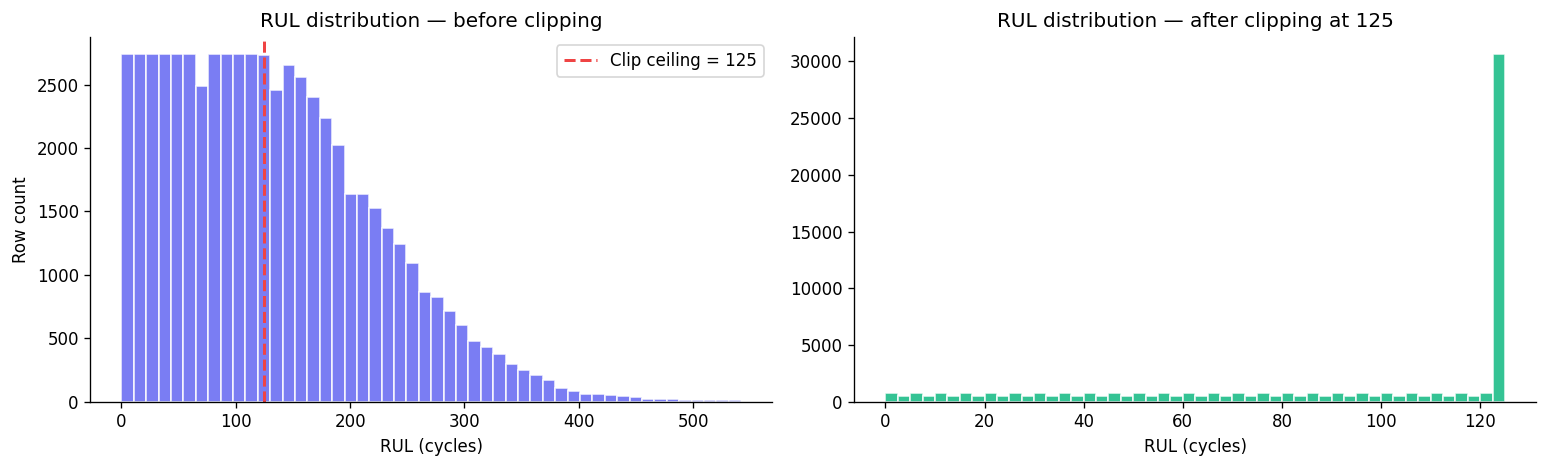

Rows clipped: 29,875  (48.8% of training data)


In [45]:
max_rul = cfg["max_rul"]
rul_raw = train_raw["RUL"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(rul_raw, bins=50, color="#6366F1", edgecolor="white", alpha=0.85)
axes[0].axvline(max_rul, color="#EF4444", linewidth=1.8, linestyle="--",
                label=f"Clip ceiling = {max_rul}")
axes[0].set_title("RUL distribution — before clipping")
axes[0].set_xlabel("RUL (cycles)")
axes[0].set_ylabel("Row count")
axes[0].legend()

axes[1].hist(rul_raw.clip(upper=max_rul), bins=50,
             color="#10B981", edgecolor="white", alpha=0.85)
axes[1].set_title(f"RUL distribution — after clipping at {max_rul}")
axes[1].set_xlabel("RUL (cycles)")

plt.tight_layout()
plt.show()

n_clipped = (rul_raw > max_rul).sum()
print(f"Rows clipped: {n_clipped:,}  ({n_clipped / len(rul_raw) * 100:.1f}% of training data)")

## 3. Run Feature Engineering

In [ ]:
train_fe, test_fe = feature_engineering(train_raw.copy(), test_raw.copy(), cfg)

new_cols = sorted(set(train_fe.columns) - set(train_raw.columns))
base_sensors = [c for c in train_raw.columns if c.startswith("sensor_")]

rolling_cols = [c for c in new_cols if "_rolling_" in c]
lag_cols = [c for c in new_cols if "_lag"      in c]
delta_cols = [c for c in new_cols if "_delta"    in c]
cycle_cols = [c for c in new_cols if c.startswith("log_")]

summary = pd.DataFrame({
    "Category": [
        "Base sensors (survived low-var filter)",
        f"Rolling mean + std  (window={cfg.get('window_size', 30)})",
        "Lag features (lag1, lag2)",
        "Delta features",
        "Cycle features (log_cycles)",
    ],
    "Count": [
        len(base_sensors), len(rolling_cols),
        len(lag_cols), len(delta_cols), len(cycle_cols),
    ],
})
summary["Cumulative"] = summary["Count"].cumsum()
print(summary.to_string(index=False))
print(f"\nTotal model-facing features : "
      f"{len([c for c in train_fe.columns if c not in ['unit_number','time_in_cycles','RUL','op_cluster']])}")
print(f"Train rows : {len(train_fe):,}")
print(f"Test rows: {len(test_fe):,}")

c:\Users\sirde\Projects\Predictive Maintenance\notebooks\..\src\data\feature_engineering.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[sensor + "_lag1"] = grouped.transform(lambda x: x.shift(1))
c:\Users\sirde\Projects\Predictive Maintenance\notebooks\..\src\data\feature_engineering.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[sensor + "_lag2"] = grouped.transform(lambda x: x.shift(2))
c:\Users\sirde\Projects\Predictive Maintenance\notebooks\..\src\data\feature_engineering.py:33: PerformanceWarning: DataFram

                              Category  Count  Cumulative
Base sensors (survived low-var filter)     20          20
       Rolling mean + std  (window=50)     40          60
             Lag features (lag1, lag2)     40         100
                        Delta features     20         120
           Cycle features (log_cycles)      1         121

Total model-facing features : 124
Train rows                  : 60,751
Test  rows                  : 40,718


c:\Users\sirde\Projects\Predictive Maintenance\notebooks\..\src\data\feature_engineering.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[sensor + "_lag1"] = grouped.transform(lambda x: x.shift(1))
c:\Users\sirde\Projects\Predictive Maintenance\notebooks\..\src\data\feature_engineering.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[sensor + "_lag2"] = grouped.transform(lambda x: x.shift(2))
c:\Users\sirde\Projects\Predictive Maintenance\notebooks\..\src\data\feature_engineering.py:33: PerformanceWarning: DataFram

## 4. Sensor Trajectories — Raw vs Rolling

The rolling mean smooths cycle-to-cycle noise. The shaded ±1σ band shows
sensor volatility — a widening band near end of life can itself be a degradation signal.

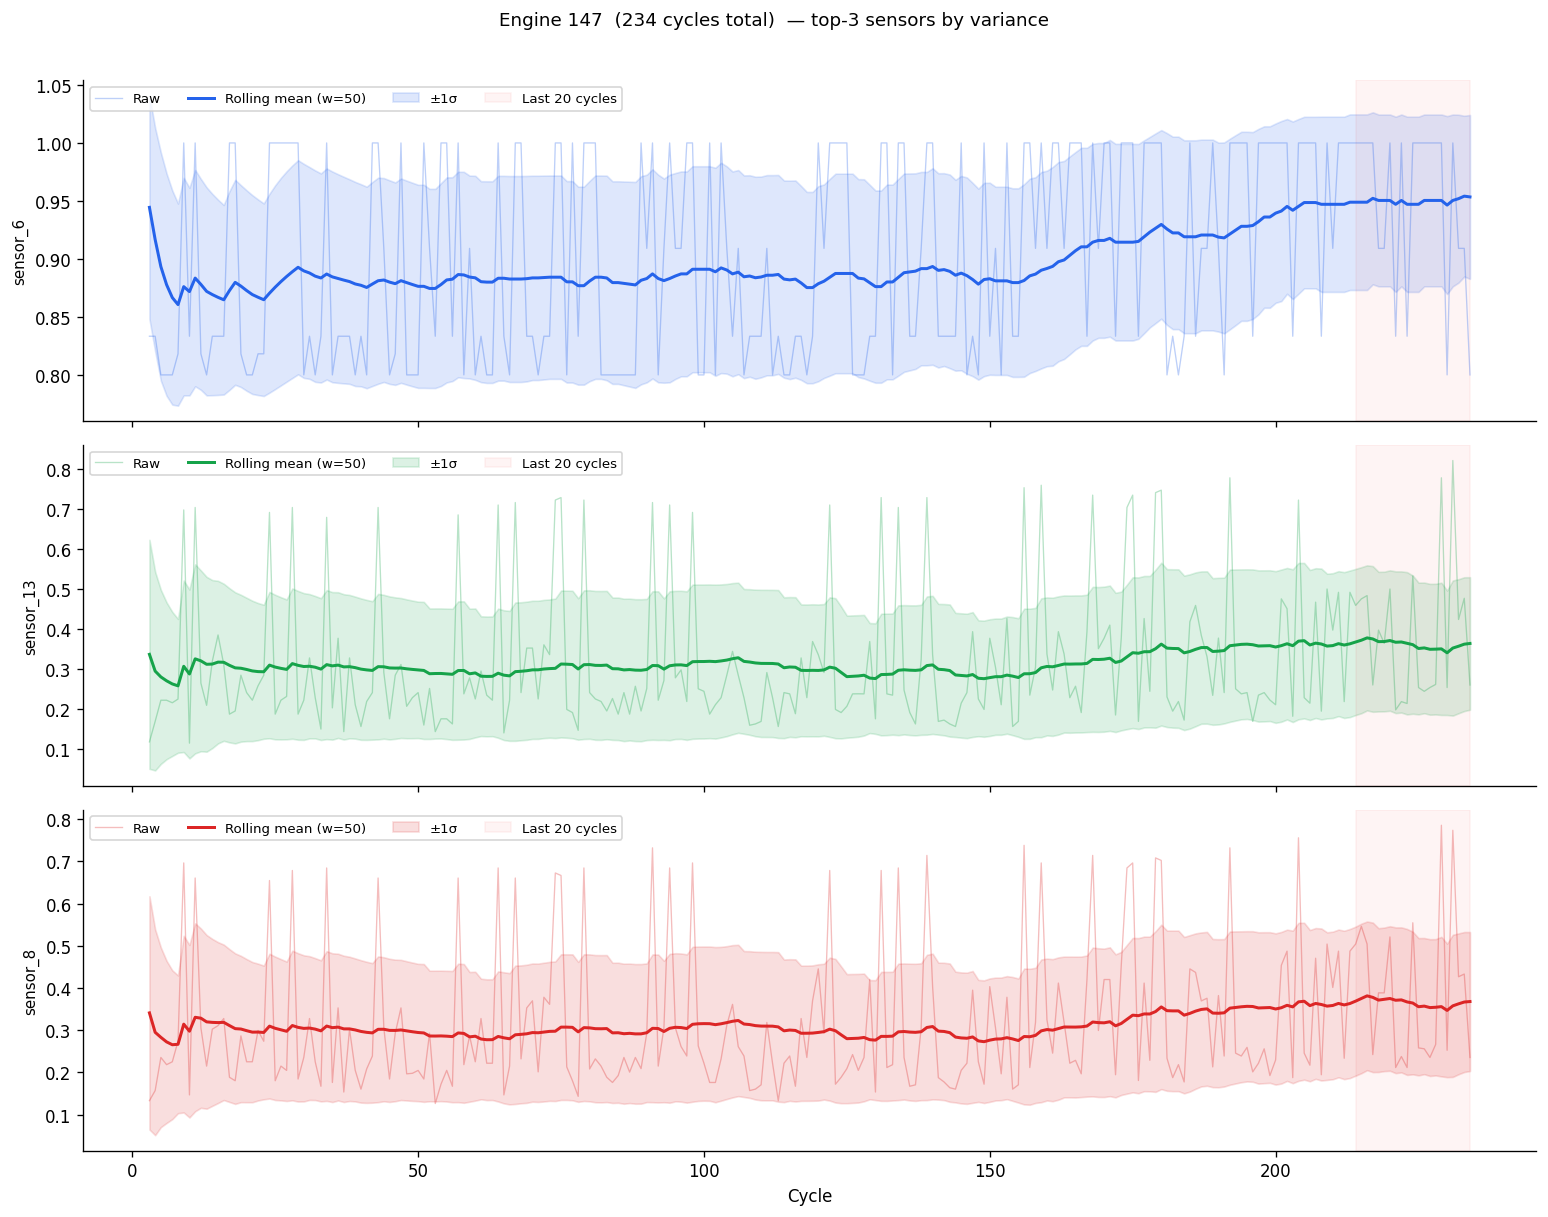

In [ ]:
# Engine with median lifespan — representative, not an outlier
engine_lengths = train_fe.groupby("unit_number")["time_in_cycles"].max()
median_engine = (engine_lengths - engine_lengths.median()).abs().idxmin()
engine_df = (train_fe[train_fe["unit_number"] == median_engine]
                  .sort_values("time_in_cycles"))

# 3 sensors with highest training-set variance
top_sensors = train_fe[base_sensors].var().nlargest(3).index.tolist()

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, sensor, color in zip(axes, top_sensors, PALETTE):
    cycles = engine_df["time_in_cycles"]
    rm = engine_df[f"{sensor}_rolling_mean"]
    rs = engine_df[f"{sensor}_rolling_std"].fillna(0)

    ax.plot(cycles, engine_df[sensor],
            alpha=0.30, color=color, linewidth=0.8, label="Raw")
    ax.plot(cycles, rm, color=color, linewidth=1.8,
            label=f"Rolling mean (w={cfg.get('window_size', 30)})")
    ax.fill_between(cycles, rm - rs, rm + rs,
                    alpha=0.15, color=color, label="±1σ")
    ax.axvspan(cycles.max() - 20, cycles.max(),
               alpha=0.06, color="#EF4444", label="Last 20 cycles")
    ax.set_ylabel(sensor, fontsize=9)
    ax.legend(loc="upper left", fontsize=8, ncol=4)

axes[-1].set_xlabel("Cycle")
fig.suptitle(
    f"Engine {median_engine}  ({int(engine_lengths[median_engine])} cycles total)  "
    "— top-3 sensors by variance",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

## 5. Delta Features — Rate-of-Change Signal

Delta = current reading minus previous cycle. A sensor that drifts monotonically
as the engine degrades should show increasingly non-zero deltas as RUL → 0.
Colour encodes cycle number (darker = earlier in life).

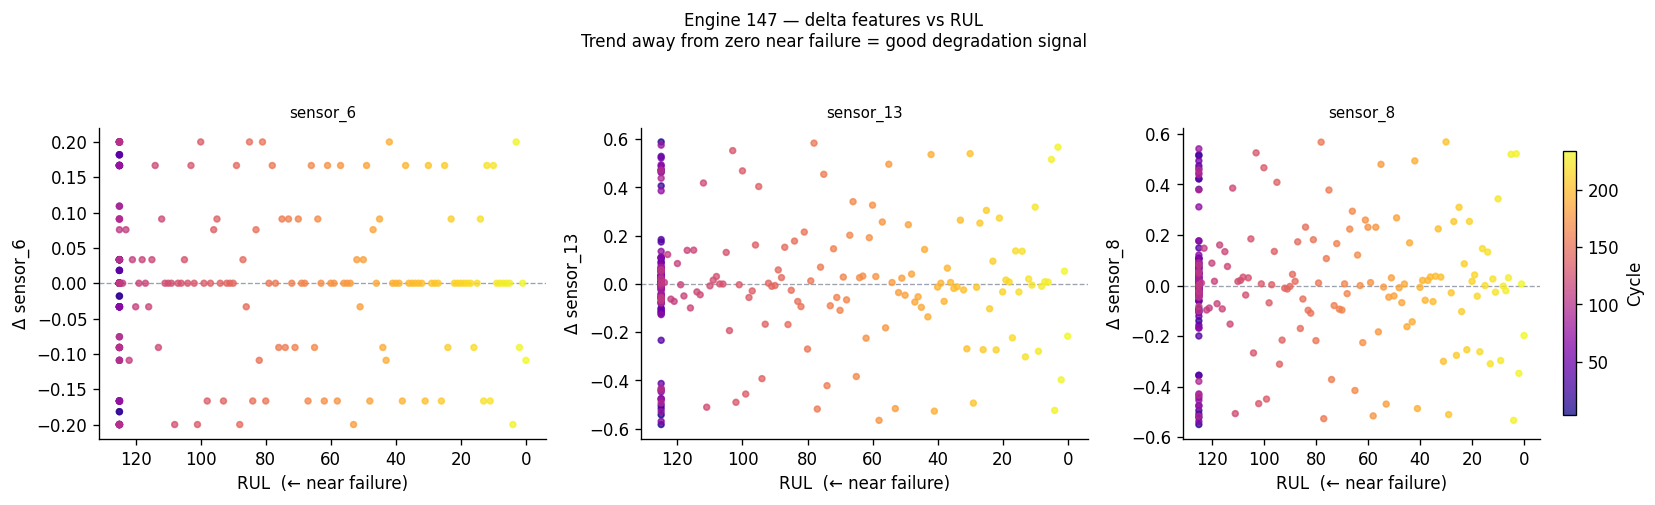

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, sensor, color in zip(axes, top_sensors, PALETTE):
    sc = ax.scatter(
        engine_df["RUL"],
        engine_df[f"{sensor}_delta"],
        c=engine_df["time_in_cycles"],
        cmap="plasma", s=12, alpha=0.75, zorder=3,
    )
    ax.axhline(0, color="#9CA3AF", linewidth=0.8, linestyle="--")
    ax.set_xlabel("RUL  (near failure)")
    ax.set_ylabel(f"Δ {sensor}")
    ax.invert_xaxis()
    ax.set_title(sensor, fontsize=9)

plt.colorbar(sc, ax=axes[-1], label="Cycle", shrink=0.85)
fig.suptitle(
    f"Engine {median_engine} — delta features vs RUL\n"
    "Trend away from zero near failure = good degradation signal",
    fontsize=10, y=1.04,
)
plt.tight_layout()
plt.show()

## 6. Sensor Variance — What Survived the Filter

Low-variance sensors carry no degradation signal and were dropped in `preprocessing.py`.
This chart confirms which survived and shows the spread in their remaining variance.

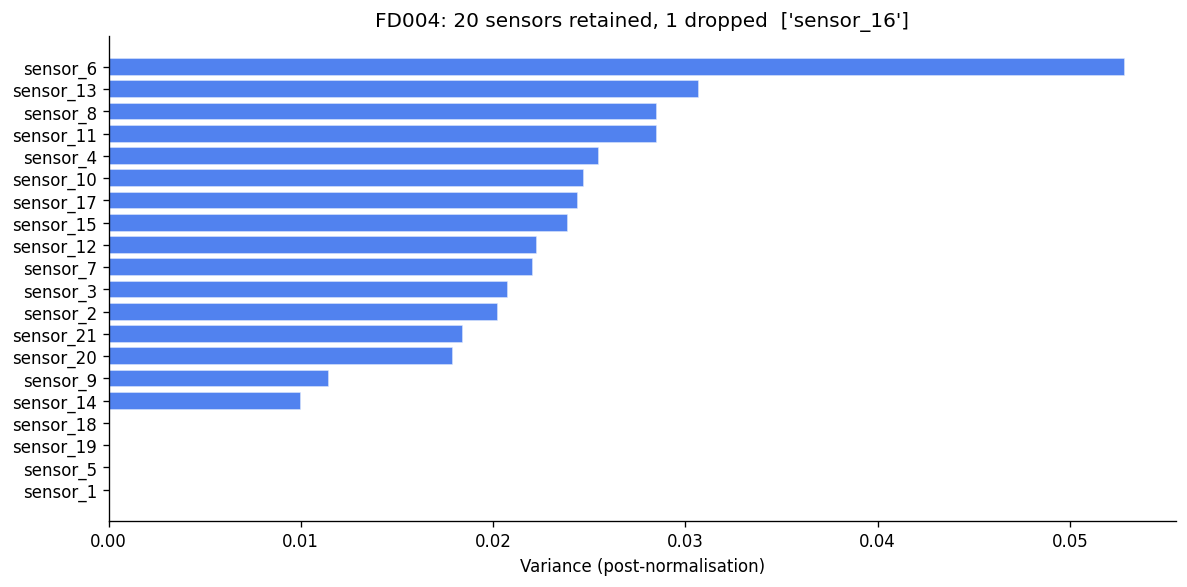

Retained : ['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
Dropped  : ['sensor_16']


In [ ]:
all_sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
surviving = [c for c in all_sensor_cols if c in train_fe.columns]
dropped = [c for c in all_sensor_cols if c not in train_fe.columns]
sensor_var = train_fe[surviving].var().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sensor_var.index, sensor_var.values,
        color="#2563EB", alpha=0.80, edgecolor="white")
ax.set_xlabel("Variance (post-normalisation)")
ax.set_title(
    f"{DATASET}: {len(surviving)} sensors retained, "
    f"{len(dropped)} dropped  {dropped}"
)
plt.tight_layout()
plt.show()
print(f"Retained : {surviving}")
print(f"Dropped  : {dropped}")

## 7. Operational Clusters

For FD001/FD003 (`n_clusters=1`) all rows are in cluster 0 — the three scatter
plots should show a single point cloud. For FD002/FD004 (`n_clusters=6`) you should
see 6 clearly separated groups, confirming per-cluster normalisation is meaningful.

C:\Users\sirde\AppData\Local\Temp\ipykernel_16048\894612887.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 1680x480 with 4 Axes> than <Figure size 1680x480 with 4 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=axes[-1], label="Cluster",


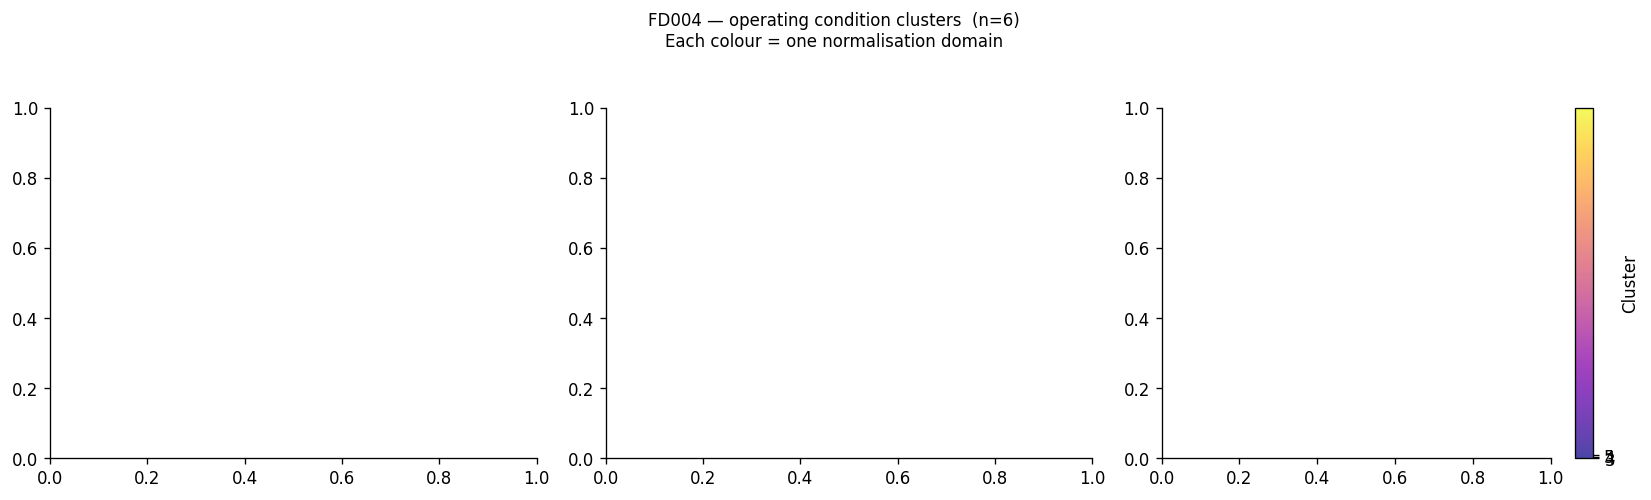

Cluster sizes (train rows):
op_cluster
0    15249
1     9156
2     9069
3     9026
4     9155
5     9096


In [50]:
op_cols = ["op_setting_1", "op_setting_2", "op_setting_3"]
pairs   = [(0, 1), (0, 2), (1, 2)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# for ax, (i, j) in zip(axes, pairs):
#     sc = ax.scatter(
#         train_raw[op_cols[i]],   # raw (pre-normalisation) for clustering plot
#         train_raw[op_cols[j]],
#         c=train_fe["op_cluster"],
#         cmap="tab10", s=4, alpha=0.4,
#     )
#     ax.set_xlabel(op_cols[i])
#     ax.set_ylabel(op_cols[j])
#     ax.set_title(f"{op_cols[i]} vs {op_cols[j]}")

plt.colorbar(sc, ax=axes[-1], label="Cluster",
             ticks=range(cfg["n_clusters"]))
fig.suptitle(
    f"{DATASET} — operating condition clusters  (n={cfg['n_clusters']})\n"
    "Each colour = one normalisation domain",
    fontsize=10, y=1.03,
)
plt.tight_layout()
plt.show()

print("Cluster sizes (train rows):")
print(train_fe["op_cluster"].value_counts().sort_index().to_string())

## 8. Feature–RUL Correlations

Pearson r with RUL across all engineered features. Rolling means and deltas
typically correlate more strongly than raw sensor values because they reduce
cycle-to-cycle noise.

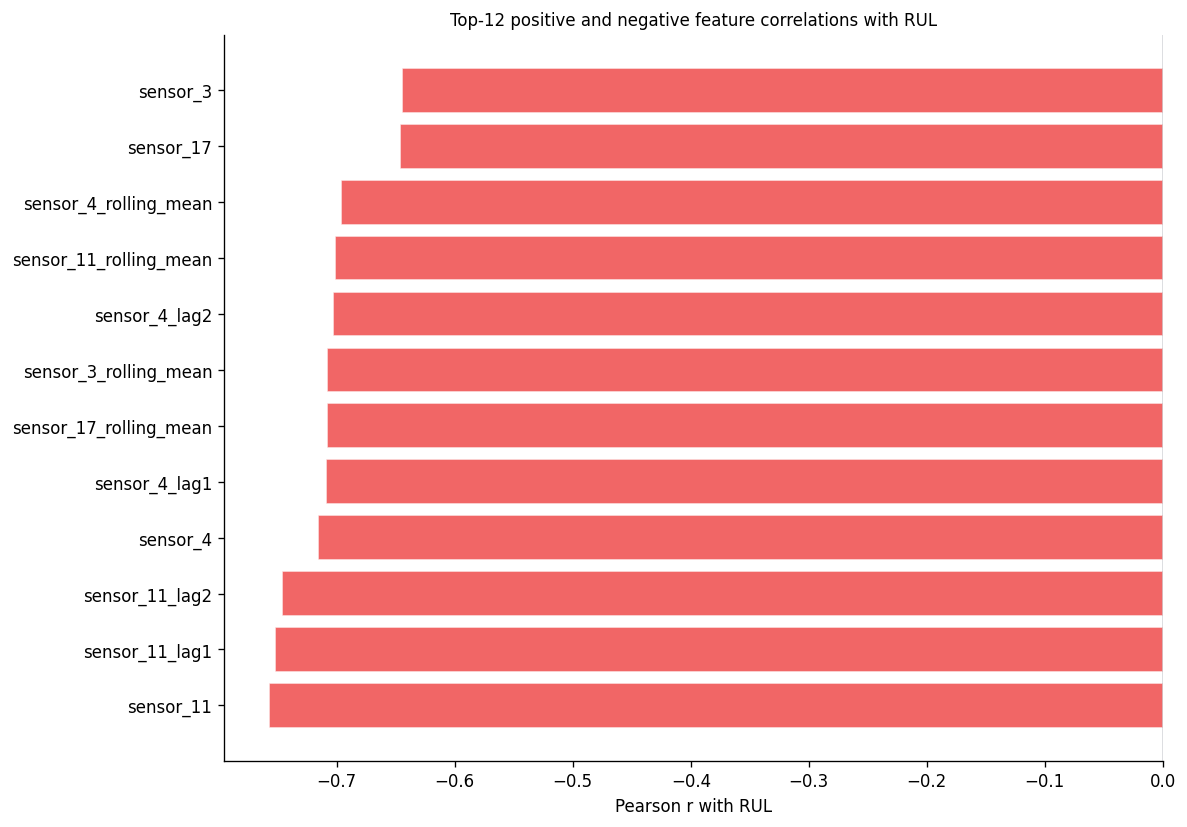

Strongest negative: sensor_11  r = -0.758
Strongest positive: sensor_6_rolling_std  r = 0.085


In [51]:
NON_FEAT = (
    {"unit_number", "time_in_cycles", "RUL", "op_cluster"}
    | {c for c in train_fe.columns if c.startswith("op_setting_")}
)
feat_cols = [c for c in train_fe.columns if c not in NON_FEAT]

corrs = (
    train_fe[feat_cols + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values()
)

top = pd.concat([corrs.head(12), corrs.tail(12)])
bar_colors = ["#EF4444" if v < 0 else "#10B981" for v in top.values]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top.index, top.values, color=bar_colors, alpha=0.82, edgecolor="white")
ax.axvline(0, color="#374151", linewidth=0.8)
ax.set_xlabel("Pearson r with RUL")
ax.set_title("Top-12 positive and negative feature correlations with RUL", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Strongest negative: {corrs.idxmin()}  r = {corrs.min():.3f}")
print(f"Strongest positive: {corrs.idxmax()}  r = {corrs.max():.3f}")

## 9. Fleet-wide Degradation Trajectories

All training engines overlaid and aligned by RUL (not cycle number).
The most-correlated feature should show a consistent fleet trend converging
near RUL = 0 — this is the signal the LSTM will learn to exploit across variable-length engine histories.

Most correlated feature: sensor_11  (r = -0.758)


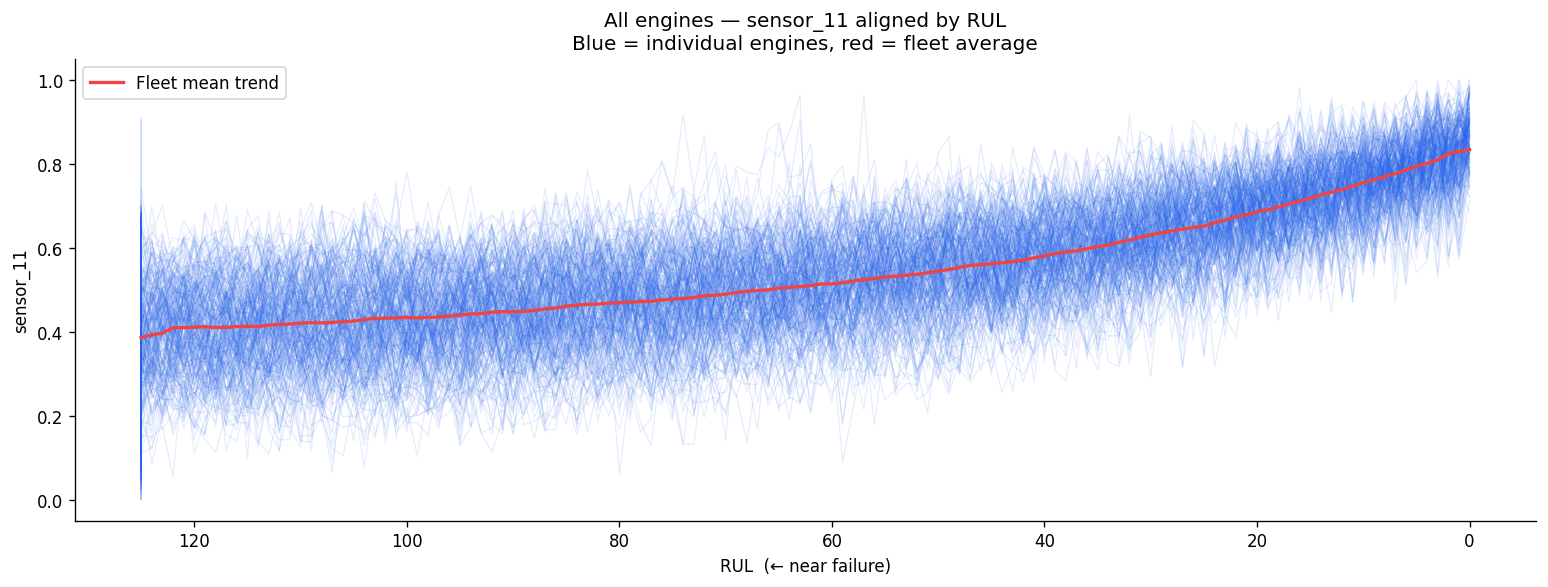

In [ ]:
best_feature = corrs.abs().idxmax()
print(f"Most correlated feature: {best_feature}  (r = {corrs[best_feature]:.3f})")

fig, ax = plt.subplots(figsize=(13, 5))

for unit in train_fe["unit_number"].unique():
    unit_data = (train_fe[train_fe["unit_number"] == unit].sort_values("RUL", ascending=False))
    ax.plot(unit_data["RUL"], unit_data[best_feature],
            alpha=0.12, color="#2563EB", linewidth=0.7)

# Fleet mean trend
trend = (
    train_fe.groupby("RUL")[best_feature]
    .mean()
    .rolling(5, center=True, min_periods=1)
    .mean()
)
ax.plot(trend.index, trend.values,
        color="#EF4444", linewidth=2.0, label="Fleet mean trend")

ax.invert_xaxis()
ax.set_xlabel("RUL  (← near failure)")
ax.set_ylabel(best_feature)
ax.set_title(
    f"All engines — {best_feature} aligned by RUL\n"
    "Blue = individual engines, red = fleet average"
)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Data Quality Validation

In [ ]:
print("=" * 50)
print(f"  DATA QUALITY REPORT — {DATASET}")
print("=" * 50)

for name, df in [("Train", train_fe), ("Test", test_fe)]:
    null_total = df.isnull().sum().sum()
    null_cols  = df.columns[df.isnull().any()].tolist()
    rul_ok     = df["RUL"].max() <= cfg["max_rul"]

    print(f"\n  {name}")
    print(f"    Shape         : {df.shape}")
    print(f"    Nulls : {null_total}"
          + (f" {null_cols}" if null_cols else "  0"))
    print(f"    RUL range     : [{df['RUL'].min():.0f}, {df['RUL'].max():.0f}]")
    print(f"    RUL clipped   : {'1' if rul_ok else '0  CHECK CLIPPING'}")
    print(f"    op_cluster    : {sorted(df['op_cluster'].unique())}")

print()
assert train_fe.isnull().sum().sum() == 0, "NaN values in train!"
assert test_fe.isnull().sum().sum()  == 0, "NaN values in test!"
assert train_fe["RUL"].max() <= cfg["max_rul"]
assert test_fe["RUL"].max()  <= cfg["max_rul"]
print("  All assertions passed.")

  DATA QUALITY REPORT — FD004

  Train
    Shape         : (60751, 128)
    Nulls         : 0  ✓
    RUL range     : [0, 125]
    RUL clipped   : ✓
    op_cluster    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

  Test
    Shape         : (40718, 128)
    Nulls         : 0  ✓
    RUL range     : [6, 125]
    RUL clipped   : ✓
    op_cluster    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

  All assertions passed.


## 11. Save Feature Files

In [ ]:
out_dir = PROCESSED_DIR / DATASET
out_dir.mkdir(parents=True, exist_ok=True)

train_fe.to_csv(out_dir / "train_features.csv", index=False)
test_fe.to_csv(out_dir  / "test_features.csv", index=False)

print(f"Saved: {out_dir}/train_features.csv {train_fe.shape}")
print(f"Saved: {out_dir}/test_features.csv {test_fe.shape}")
print(f"\nNext: python src/training/train.py --dataset {DATASET} --model all")

Saved: c:\Users\sirde\Projects\Predictive Maintenance\data\processed\FD004/train_features.csv  (60751, 128)
Saved: c:\Users\sirde\Projects\Predictive Maintenance\data\processed\FD004/test_features.csv   (40718, 128)

Next: python src/training/train.py --dataset FD004 --model all
